---
title: 
author: Samantha Pang
date: 2026-01-15
date-modified: last-modified 
format: 
    html: 
        toc: true
        code-fold: true
---

In [ ]:
import pandas as pd
import yfinance as yf
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# # US Treasury Rates Data Preparation
# df_trea = pd.read_csv('clean_US_Treasury_Rates.csv')
# df_trea = df_trea[['Date', '2 Yr', '10 Yr']].dropna()
# df_trea.columns = ['Date', 'T2', 'T10']
# df_trea['Spread'] = df_trea['T10'] - df_trea['T2']
# df_trea['Date'] = pd.to_datetime(df_trea['Date'])

# # sp500 Data Preparation
# startdate = df_trea['Date'].min()
# enddate = df_trea['Date'].max()
# df_sp500 = yf.download(["^GSPC"], start=startdate, end=enddate, auto_adjust=True)["Close"]
# df_sp500.columns = ['Close']

# # Compute daily S&P 500 returns
# df_sp500['Return'] = df_sp500['Close'].pct_change()  # (Close_t - Close_t-1)/Close_t-1

# # Label returns: Up / Down / Neutral
# def label_return(r):
#     if r > 0.002:       # 0.2%
#         return 'Up'
#     elif r < -0.002:
#         return 'Down'
#     else:
#         return 'Neutral'

# df_sp500['Label'] = df_sp500['Return'].apply(label_return)
# df_sp500.reset_index(inplace=True)

[*********************100%***********************]  1 of 1 completed


c:\Users\neh2k\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\neh2k\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
[*********************100%***********************]  1 of 1 completed


<Axes: xlabel='Date'>

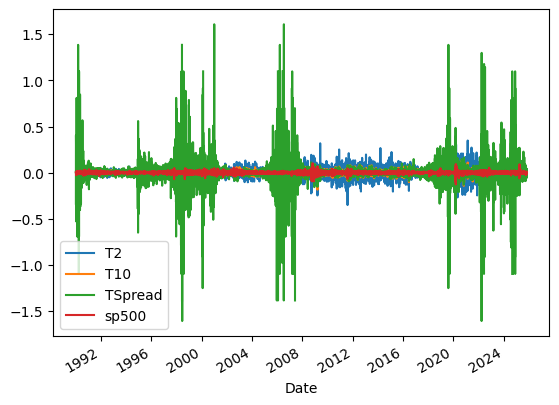

In [19]:
import numpy as np

def returns(prices):
    return np.log(prices/prices.shift(1))

# US Treasury Rates Data Preparation
df_trea = pd.read_csv('clean_US_Treasury_Rates.csv')
df_trea = df_trea[['Date','2 Yr', '10 Yr']].dropna()
df_trea['Spread'] = df_trea['10 Yr'] - df_trea['2 Yr']
df_trea['Date'] = pd.to_datetime(df_trea['Date'])

for col in df_trea.columns[1:]:
    df_trea[col] = returns(df_trea[col])
df_trea.columns = ['Date', 'T2', 'T10', 'TSpread']

# # sp500 Data Preparation
startdate = df_trea['Date'].min()
enddate = df_trea['Date'].max()
df_sp500 = yf.download(["^GSPC"], start=startdate, end=enddate, auto_adjust=True)["Close"]
df_sp500.columns = ['sp500']
df_sp500.reset_index(inplace=True)
df_sp500['sp500'] = returns(df_sp500['sp500'])

df = df_trea.merge(df_sp500, how='left')
df.dropna(inplace=True)
df.plot(x='Date', y=['T2', 'T10', 'TSpread','sp500'])

In [28]:
data = df.melt(id_vars='Date', var_name='Series', value_name='Value')
data = data[data['Series'].isin(['T2','T10', 'sp500'])]
data.dropna(inplace=True)

import plotly.express as px

fig = px.line(
    data,
    x='Date',
    y='Value',
    color='Series',
    title="US Treasury Rates and S&P 500 Returns Over Time",
    color_discrete_sequence=px.colors.sequential.Rainbow_r
)

fig.add_hline(y=0, line_dash='dash', line_color='gray')

# Improve layout and interactivity
fig.update_layout(
    # width=1000,
    # height=700,
    yaxis_title="Log Returns",
    # legend_title="Series",
    hovermode="x unified",
    template="plotly_white",
)
fig.update_yaxes(range=[-.5, .5])
# Add range slider and zoom buttons for date axis
fig.update_xaxes(
    rangeslider_visible=True,
    rangeselector=dict(
        buttons=list([
            dict(count=1, label="1y", step="year", stepmode="backward"),
            dict(count=5, label="5y", step="year", stepmode="backward"),
            dict(step="all")
        ])
    )
)

# fig.update_xaxes(range=[data['Date'].max() - pd.DateOffset(years=5), data['Date'].max()])
fig.show()

In [2]:
df = pd.merge(df_sp500, df_trea, on='Date').dropna()
df

,Date,Close,Return,Label,T2,T10,Spread
1,1990-01-03,358.760010,-0.002586,Down,7.94,7.99,0.05
2,1990-01-04,355.670013,-0.008613,Down,7.92,7.98,0.06
3,1990-01-05,352.200012,-0.009756,Down,7.90,7.99,0.09
4,1990-01-08,353.790009,0.004514,Up,7.90,8.02,0.12
5,1990-01-09,349.619995,-0.011787,Down,7.91,8.02,0.11
...,...,...,...,...,...,...,...
8952,2025-11-03,6851.970215,0.001721,Neutral,3.60,4.13,0.53
8953,2025-11-04,6771.549805,-0.011737,Down,3.58,4.10,0.52
8954,2025-11-05,6796.290039,0.003654,Up,3.63,4.17,0.54
8955,2025-11-06,6720.319824,-0.011178,Down,3.57,4.11,0.54


In [44]:
# 5. Features and target
X = df[['T2', 'T10', 'Spread']]
y = df['Label']

# 6. Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)  # Time series style

# 7. Train Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 8. Predict & evaluate
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

# 9. Feature importance
importance = pd.Series(model.feature_importances_, index=X.columns)
print("Feature importance:\n", importance)


              precision    recall  f1-score   support

        Down       0.34      0.27      0.30       628
     Neutral       0.23      0.22      0.22       379
          Up       0.44      0.52      0.48       785

    accuracy                           0.37      1792
   macro avg       0.34      0.34      0.33      1792
weighted avg       0.36      0.37      0.36      1792

Feature importance:
 T2        0.333650
T10       0.343943
Spread    0.322407
dtype: float64
